# 02 Core EDA, Weighted
Focuses on retrospective operational conditions that affect wait time, using PATWT-weighted summaries and bottleneck tests.

Prerequisite: run 01_data_prep.ipynb first.

In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

data_dir = Path('../data')
eda_path = data_dir / 'eda_df.csv'
retro_path = data_dir / 'model_B_retrospective_dataset.csv'

eda_df = pd.read_csv(eda_path)
model_B_df = pd.read_csv(retro_path) if retro_path.exists() else pd.DataFrame()

if 'PATWT' not in eda_df.columns:
    raise ValueError('PATWT column not found in eda_df; weighted EDA cannot run.')

analysis_df = eda_df.copy()
analysis_df['PATWT'] = pd.to_numeric(analysis_df['PATWT'], errors='coerce')
analysis_df = analysis_df.dropna(subset=['PATWT'])
analysis_df = analysis_df[analysis_df['PATWT'] > 0].copy()

def weighted_mean(values, weights):
    values = pd.to_numeric(pd.Series(values), errors='coerce')
    weights = pd.to_numeric(pd.Series(weights), errors='coerce')
    mask = values.notna() & weights.notna() & (weights > 0)
    if not mask.any():
        return np.nan
    return np.average(values[mask], weights=weights[mask])

def weighted_quantile(values, weights, quantile):
    values = pd.to_numeric(pd.Series(values), errors='coerce')
    weights = pd.to_numeric(pd.Series(weights), errors='coerce')
    mask = values.notna() & weights.notna() & (weights > 0)
    if not mask.any():
        return np.nan
    values = values[mask].to_numpy()
    weights = weights[mask].to_numpy()
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cumulative = np.cumsum(weights)
    cutoff = quantile * weights.sum()
    return np.interp(cutoff, cumulative, values)

def weighted_missing_share(frame, column, weight_col='PATWT'):
    valid = frame[weight_col].sum()
    if valid == 0:
        return np.nan
    return frame.loc[frame[column].isna(), weight_col].sum() / valid

def weighted_group_summary(frame, group_col, value_col='WAITTIME', weight_col='PATWT'):
    subset = frame[[group_col, value_col, weight_col]].copy()
    subset[group_col] = subset[group_col].astype('object').fillna('Missing')

    def summarize(group):
        return pd.Series({
            'weighted_n': group[weight_col].sum(),
            'weighted_mean': weighted_mean(group[value_col], group[weight_col]),
            'weighted_median': weighted_quantile(group[value_col], group[weight_col], 0.5),
            'weighted_p75': weighted_quantile(group[value_col], group[weight_col], 0.75)
        })

    summary = subset.groupby(group_col, dropna=False).apply(summarize).reset_index()
    summary['weighted_share'] = summary['weighted_n'] / summary['weighted_n'].sum()
    return summary.sort_values('weighted_n', ascending=False)

def weighted_corr(frame, columns, weight_col='PATWT'):
    clean = frame[columns + [weight_col]].copy()
    clean = clean.apply(pd.to_numeric, errors='coerce')
    matrix = pd.DataFrame(index=columns, columns=columns, dtype=float)
    for left in columns:
        for right in columns:
            if left == right:
                matrix.loc[left, right] = 1.0
                continue
            pair = clean[[left, right, weight_col]].dropna()
            pair = pair[pair[weight_col] > 0]
            if pair.empty:
                matrix.loc[left, right] = np.nan
                continue
            x = pair[left].to_numpy(dtype=float).reshape(-1)
            y = pair[right].to_numpy(dtype=float).reshape(-1)
            w = pair[weight_col].to_numpy(dtype=float).reshape(-1)
            x_mean = np.average(x, weights=w)
            y_mean = np.average(y, weights=w)
            cov = np.average((x - x_mean) * (y - y_mean), weights=w)
            x_var = np.average((x - x_mean) ** 2, weights=w)
            y_var = np.average((y - y_mean) ** 2, weights=w)
            matrix.loc[left, right] = cov / np.sqrt(x_var * y_var) if x_var > 0 and y_var > 0 else np.nan
    return matrix

print('eda_df shape:', eda_df.shape)
print('analysis_df shape after PATWT filtering:', analysis_df.shape)
print('model_B_df shape:', model_B_df.shape)
print('PATWT total weight:', analysis_df['PATWT'].sum())

eda_df shape: (91812, 36)
analysis_df shape after PATWT filtering: (91812, 36)
model_B_df shape: (91812, 33)
PATWT total weight: 728560562.24158


In [15]:
summary_cols = [c for c in ['WAITTIME', 'FASTTRAK', 'OBSCLIN', 'BOARD', 'ADMIT', 'MRI', 'XRAY', 'CT', 'CTCONTRAST', 'ULTRASOUND', 'ANYIMAGE', 'LABTEST', 'TOTPROC', 'BEDREG', 'IMBED', 'BEDCZAR'] if c in analysis_df.columns]
weighted_summary = []
for col in summary_cols:
    weighted_summary.append({
        'feature': col,
        'weighted_mean': weighted_mean(analysis_df[col], analysis_df['PATWT']),
        'weighted_median': weighted_quantile(analysis_df[col], analysis_df['PATWT'], 0.5),
        'weighted_p25': weighted_quantile(analysis_df[col], analysis_df['PATWT'], 0.25),
        'weighted_p75': weighted_quantile(analysis_df[col], analysis_df['PATWT'], 0.75),
        'weighted_missing_share': weighted_missing_share(analysis_df, col)
    })
weighted_summary = pd.DataFrame(weighted_summary)
display(weighted_summary)

weighted_missingness = pd.DataFrame({
    'feature': analysis_df.columns,
    'weighted_missing_share': [weighted_missing_share(analysis_df, col) for col in analysis_df.columns]
}).sort_values('weighted_missing_share', ascending=False)
display(weighted_missingness.head(20))

retrospective_columns = [c for c in ['WAITTIME', 'FASTTRAK', 'OBSCLIN', 'BOARD', 'ADMIT', 'MRI', 'XRAY', 'CT', 'CTCONTRAST', 'ULTRASOUND', 'ANYIMAGE', 'LABTEST', 'TOTPROC', 'BEDREG', 'IMBED', 'BEDCZAR'] if c in analysis_df.columns]
if retrospective_columns:
    retrospective_presence = pd.DataFrame({
        'feature': retrospective_columns,
        'weighted_nonmissing_share': [1 - weighted_missing_share(analysis_df, col) for col in retrospective_columns]
    }).sort_values('weighted_nonmissing_share', ascending=False)
    display(retrospective_presence)

,feature,weighted_mean,weighted_median,weighted_p25,weighted_p75,weighted_missing_share
0,WAITTIME,34.695350,16.0,6.0,41.0,0.0
1,FASTTRAK,0.662969,1.0,1.0,2.0,0.0
2,OBSCLIN,0.887977,1.0,1.0,2.0,0.0
3,BOARD,0.471674,1.0,1.0,1.0,0.0
4,ADMIT,-5.907853,-7.0,-7.0,-7.0,0.0
5,MRI,0.011524,0.0,0.0,0.0,0.0
6,XRAY,0.366883,0.0,0.0,1.0,0.0
7,CTCONTRAST,-7.048606,-9.0,-9.0,-9.0,0.0
8,ANYIMAGE,0.526018,1.0,0.0,1.0,0.0
9,TOTPROC,0.384321,0.0,0.0,1.0,0.0


,feature,weighted_missing_share
33,EDWT,0.834022
16,BOARDED,0.338409
11,LOV,0.338409
0,WAITTIME,0.000000
26,BEDCZAR,0.000000
21,PULSE,0.000000
22,RESPR,0.000000
23,POPCT,0.000000
24,BEDREG,0.000000
25,IMBED,0.000000


,feature,weighted_nonmissing_share
0,WAITTIME,1.0
1,FASTTRAK,1.0
2,OBSCLIN,1.0
3,BOARD,1.0
4,ADMIT,1.0
5,MRI,1.0
6,XRAY,1.0
7,CTCONTRAST,1.0
8,ANYIMAGE,1.0
9,TOTPROC,1.0


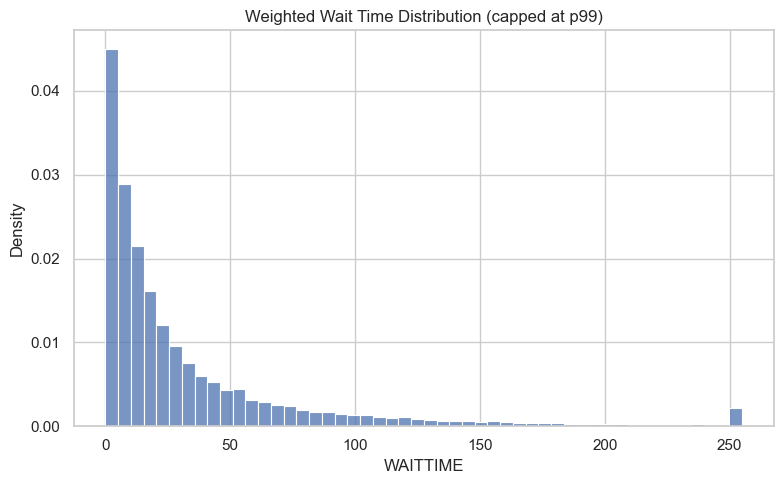

,FASTTRAK,weighted_n,weighted_mean,weighted_median,weighted_p75,weighted_share
2,1.0,4.313310e+08,34.709097,16.0,40.00000,0.592032
3,2.0,2.432038e+08,33.091967,16.0,39.00000,0.333814
1,-8.0,5.150673e+07,41.486949,20.0,52.00000,0.070697
0,-9.0,2.519099e+06,48.274141,29.0,59.32446,0.003458


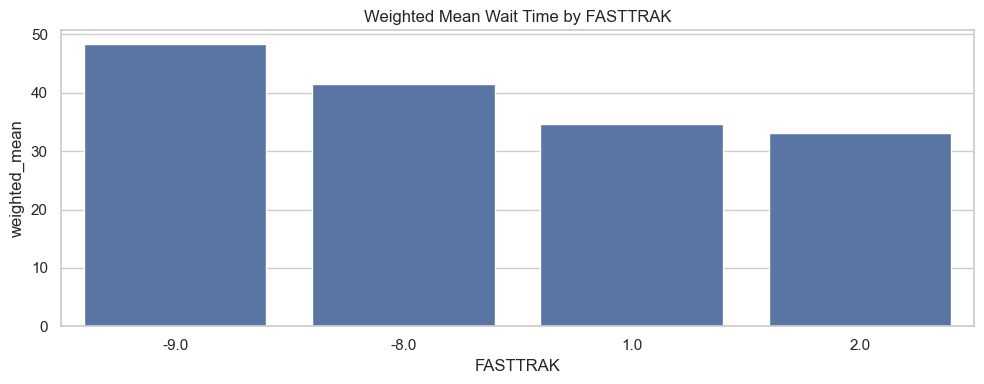

,OBSCLIN,weighted_n,weighted_mean,weighted_median,weighted_p75,weighted_share
3,2.0,3.634060e+08,32.350065,15.0,37.0,0.498800
2,1.0,3.159742e+08,37.355393,18.0,45.0,0.433697
1,-8.0,4.678205e+07,34.162757,18.0,42.0,0.064212
0,-9.0,2.398325e+06,49.998476,31.0,61.0,0.003292


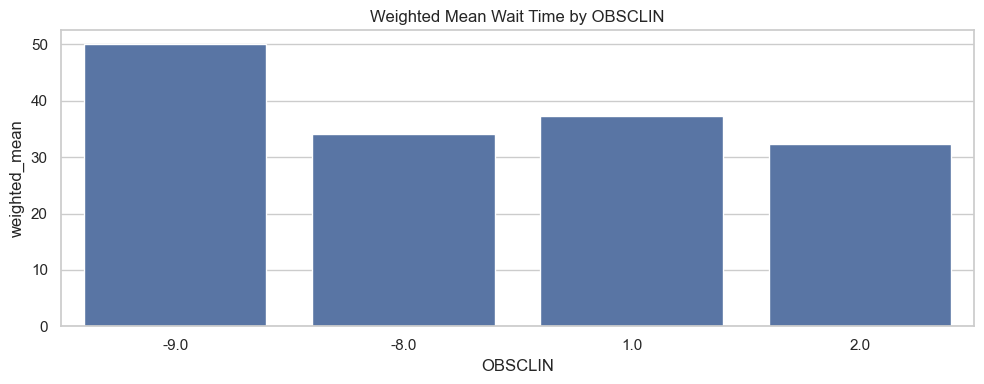

,BOARD,weighted_n,weighted_mean,weighted_median,weighted_p75,weighted_share
2,1.0,5.630434e+08,35.612253,16.0,42.0,0.772816
3,2.0,1.107135e+08,27.886867,15.0,33.0,0.151962
1,-8.0,5.240531e+07,38.527655,19.0,48.0,0.071930
0,-9.0,2.398325e+06,49.998476,31.0,61.0,0.003292


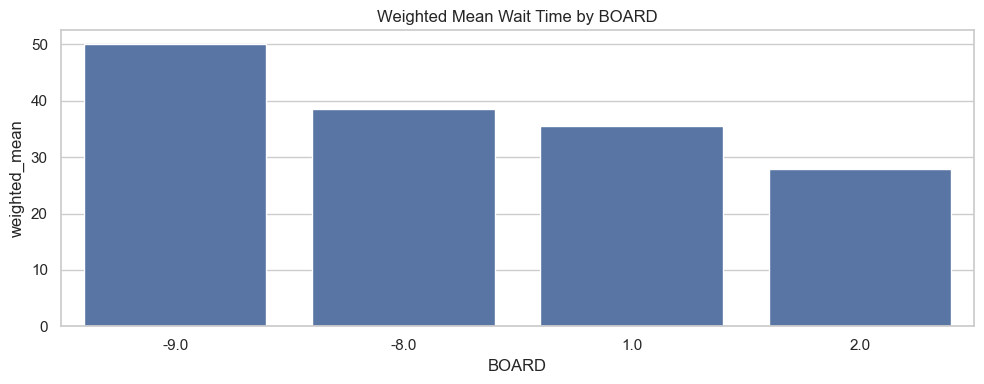

,ADMIT,weighted_n,weighted_mean,weighted_median,weighted_p75,weighted_share
2,-7.0,6.476742e+08,35.105996,17.0,42.000000,0.888978
8,6.0,4.388589e+07,32.353651,14.0,35.000000,0.060236
3,1.0,1.239845e+07,27.597612,11.0,29.000000,0.017018
1,-8.0,1.047178e+07,32.754735,14.0,36.076445,0.014373
5,3.0,6.004953e+06,29.269250,13.0,31.000000,0.008242
4,2.0,3.282400e+06,32.695688,15.0,40.000000,0.004505
6,4.0,2.714740e+06,33.919523,17.0,39.380429,0.003726
7,5.0,1.518999e+06,24.770813,11.0,20.000000,0.002085
0,-9.0,6.091317e+05,37.082450,13.0,34.247324,0.000836


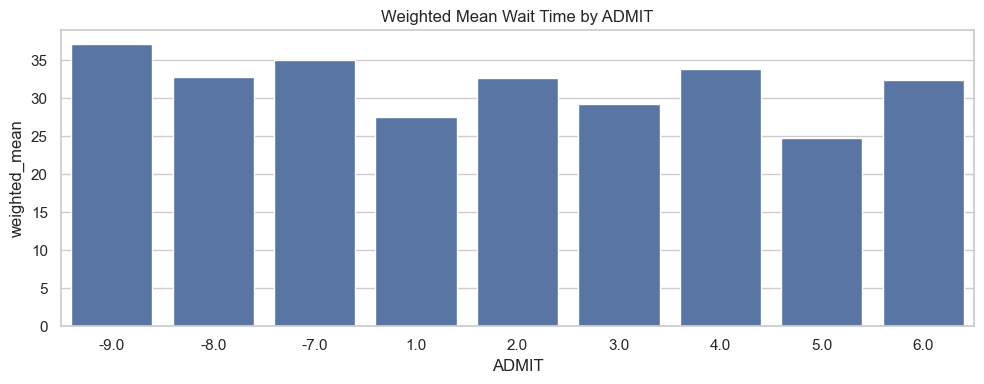

,MRI,weighted_n,weighted_mean,weighted_median,weighted_p75,weighted_share
0,0.0,7.201644e+08,34.695148,16.0,41.0,0.988476
1,1.0,8.396186e+06,34.712690,15.0,40.0,0.011524


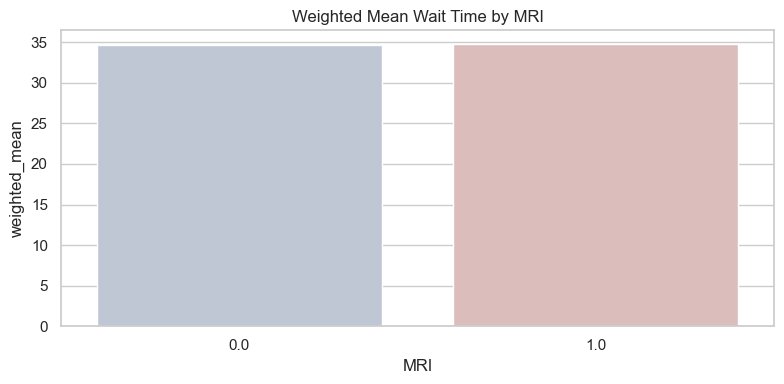

,XRAY,weighted_n,weighted_mean,weighted_median,weighted_p75,weighted_share
0,0.0,4.612640e+08,35.075221,17.0,42.0,0.633117
1,1.0,2.672966e+08,34.039821,15.0,39.0,0.366883


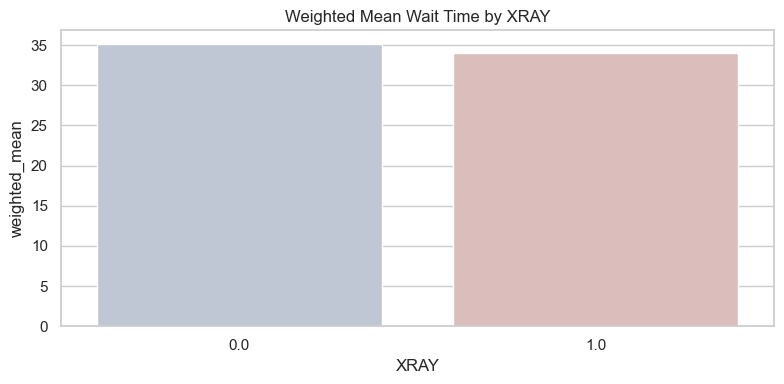

,CTCONTRAST,weighted_n,weighted_mean,weighted_median,weighted_p75,weighted_share
0,-9.0,5.862770e+08,34.913456,17.0,41.0,0.804706
3,2.0,8.678417e+07,31.504069,14.0,35.0,0.119117
2,1.0,4.573149e+07,38.966293,17.0,46.0,0.062770
1,-8.0,9.767860e+06,29.962025,12.0,30.0,0.013407


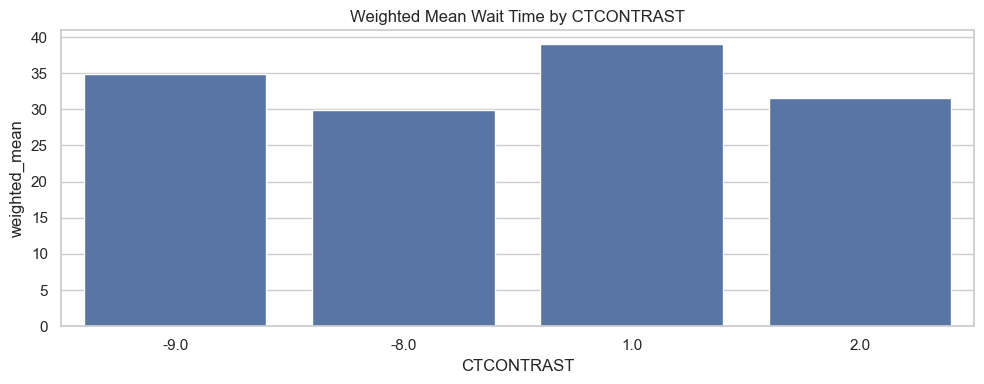

,ANYIMAGE,weighted_n,weighted_mean,weighted_median,weighted_p75,weighted_share
1,1.0,3.832360e+08,34.981767,16.0,40.0,0.526018
0,0.0,3.453246e+08,34.377489,17.0,41.0,0.473982


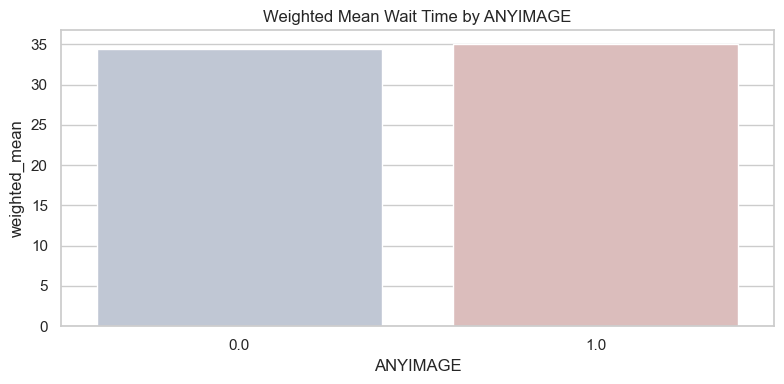

In [16]:
retrospective_plots = [c for c in ['FASTTRAK', 'OBSCLIN', 'BOARD', 'ADMIT', 'MRI', 'XRAY', 'CT', 'CTCONTRAST', 'ULTRASOUND', 'ANYIMAGE', 'LABTEST'] if c in analysis_df.columns]
if 'WAITTIME' in analysis_df.columns:
    plot_df = analysis_df[['WAITTIME', 'PATWT']].copy()
    plot_df = plot_df.dropna(subset=['WAITTIME', 'PATWT'])
    cap = plot_df['WAITTIME'].quantile(0.99)
    plot_df['WAITTIME_CAPPED'] = plot_df['WAITTIME'].clip(upper=cap)

    plt.figure(figsize=(8, 5))
    sns.histplot(data=plot_df, x='WAITTIME_CAPPED', weights='PATWT', bins=50, stat='density')
    plt.title('Weighted Wait Time Distribution (capped at p99)')
    plt.xlabel('WAITTIME')
    plt.tight_layout()
    plt.show()

for col in retrospective_plots:
    if col in analysis_df.columns:
        summary = weighted_group_summary(analysis_df, col)
        display(summary)

        if analysis_df[col].dropna().nunique() <= 2:
            plt.figure(figsize=(8, 4))
            sns.barplot(data=summary, x=col, y='weighted_mean', hue=col, dodge=False, legend=False, palette='vlag')
            plt.title(f'Weighted Mean Wait Time by {col}')
            plt.tight_layout()
            plt.show()
        else:
            plt.figure(figsize=(10, 4))
            sns.barplot(data=summary, x=col, y='weighted_mean', color='#4C72B0')
            plt.title(f'Weighted Mean Wait Time by {col}')
            plt.tight_layout()
            plt.show()

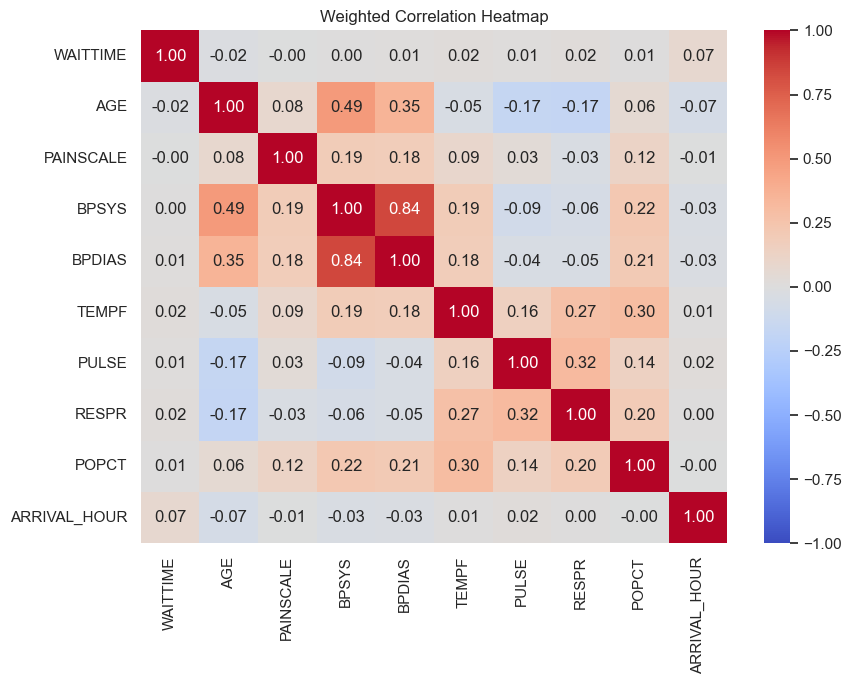

Saved: ../data/eda_gap_report.csv


In [10]:
corr_cols = [c for c in ['WAITTIME', 'AGE', 'PAINSCALE', 'BPSYS', 'BPDIAS', 'TEMPF', 'PULSE', 'RESPR', 'POPCT', 'ARRIVAL_HOUR'] if c in analysis_df.columns]
if len(corr_cols) >= 2:
    corr_matrix = weighted_corr(analysis_df, corr_cols)
    plt.figure(figsize=(9, 7))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
    plt.title('Weighted Correlation Heatmap')
    plt.tight_layout()
    plt.show()

if not model_B_df.empty and 'PATWT' in model_B_df.columns and 'WAITTIME' in model_B_df.columns:
    model_B_df = model_B_df.copy()
    model_B_df['PATWT'] = pd.to_numeric(model_B_df['PATWT'], errors='coerce')
    model_B_df = model_B_df.dropna(subset=['PATWT'])
    model_B_df = model_B_df[model_B_df['PATWT'] > 0].copy()

    for col in ['FASTTRAK', 'OBSCLIN', 'BOARD', 'ADMIT']:
        if col in model_B_df.columns:
            print(f'Weighted WAITTIME by {col}')
            display(weighted_group_summary(model_B_df, col))

out_path = Path('../data/eda_gap_report.csv')
weighted_missingness.to_csv(out_path, index=False)
print('Saved:', out_path)

,flag,positive_value,n_positive,n_negative,mean_positive,mean_negative,median_positive,median_negative,weighted_mean_positive,weighted_mean_negative,mean_diff,t_stat,p_value,cohen_d
2,BOARD,1,69553,22259,35.278838,30.337931,16.0,16.0,35.612253,31.576301,4.940907,14.277785,3.765618e-46,0.103345
1,OBSCLIN,1,38897,52915,35.433452,33.086762,16.0,16.0,37.355393,32.658190,2.346691,6.872213,6.367307e-12,0.046158
3,ADMIT,1,1506,90306,26.094954,34.214139,10.0,16.0,27.597612,34.818229,-8.119185,-6.600286,5.604175e-11,-0.165781
5,XRAY,1,32032,59780,32.956294,34.683590,15.0,16.0,34.039821,35.075221,-1.727296,-4.936515,7.972580e-07,-0.034174
6,CTCONTRAST,1,5556,86256,37.326854,33.871881,16.0,16.0,38.966293,34.409310,3.454972,4.365217,1.290913e-05,0.064014
0,FASTTRAK,1,52245,39567,34.678419,33.292062,16.0,16.0,34.709097,34.675401,1.386357,4.166883,3.090853e-05,0.027593
4,MRI,1,947,90865,37.294615,34.047466,14.0,16.0,34.712690,34.695148,3.247149,1.697298,8.996416e-02,0.059349
7,ANYIMAGE,1,46183,45629,33.953706,34.209757,15.0,17.0,34.981767,34.377489,-0.256051,-0.767478,4.427995e-01,-0.005065


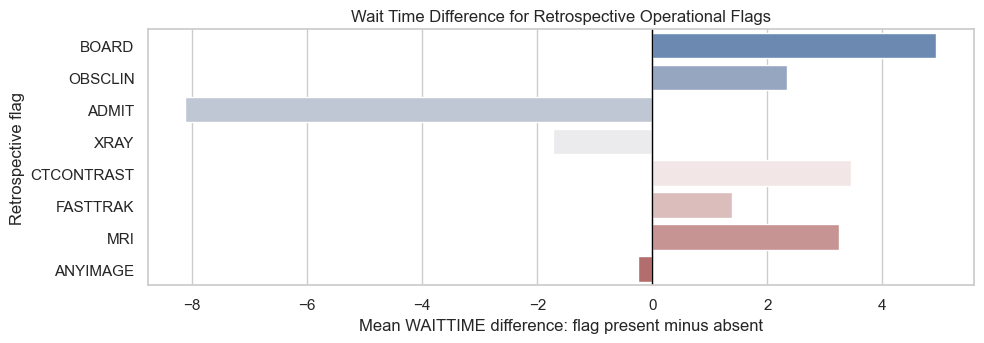

,WAITTIME,FASTTRAK,OBSCLIN,BOARD,ADMIT,MRI,XRAY,CTCONTRAST,ANYIMAGE,TOTPROC,BEDREG,IMBED,BEDCZAR
WAITTIME,1.000000,-0.044455,-0.011713,-0.036852,-0.012681,0.006488,-0.016282,-0.007124,-0.002532,-0.025844,-0.030076,-0.039269,-0.021788
FASTTRAK,-0.044455,1.000000,0.489352,0.446676,0.010214,0.001826,-0.013954,-0.021166,-0.021674,-0.011240,0.625849,0.527493,0.263824
OBSCLIN,-0.011713,0.489352,1.000000,0.420723,0.015146,0.006662,-0.008043,-0.010418,-0.017617,-0.012907,0.490387,0.419254,0.253394
BOARD,-0.036852,0.446676,0.420723,1.000000,0.001709,-0.006489,-0.014141,-0.014213,-0.023399,-0.008115,0.509748,0.425053,0.225689
ADMIT,-0.012681,0.010214,0.015146,0.001709,1.000000,0.088248,0.143185,0.143756,0.163833,0.102011,0.016509,0.018565,-0.008675
MRI,0.006488,0.001826,0.006662,-0.006489,0.088248,1.000000,0.018005,0.082373,0.101474,0.022313,0.007920,0.010696,-0.001883
XRAY,-0.016282,-0.013954,-0.008043,-0.014141,0.143185,0.018005,1.000000,0.065700,0.727601,0.108601,-0.010089,0.002692,-0.001915
CTCONTRAST,-0.007124,-0.021166,-0.010418,-0.014213,0.143756,0.082373,0.065700,1.000000,0.455135,0.102731,-0.006709,0.005543,-0.011152
ANYIMAGE,-0.002532,-0.021674,-0.017617,-0.023399,0.163833,0.101474,0.727601,0.455135,1.000000,0.139422,-0.012932,0.000456,-0.003780
TOTPROC,-0.025844,-0.011240,-0.012907,-0.008115,0.102011,0.022313,0.108601,0.102731,0.139422,1.000000,-0.009472,0.010705,-0.024208


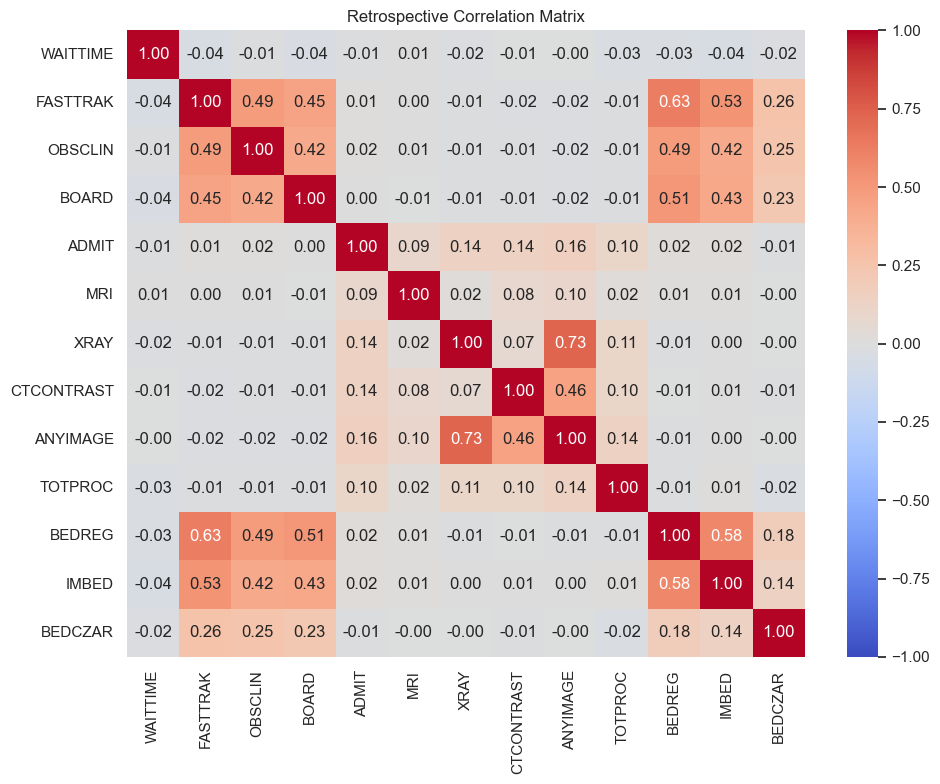

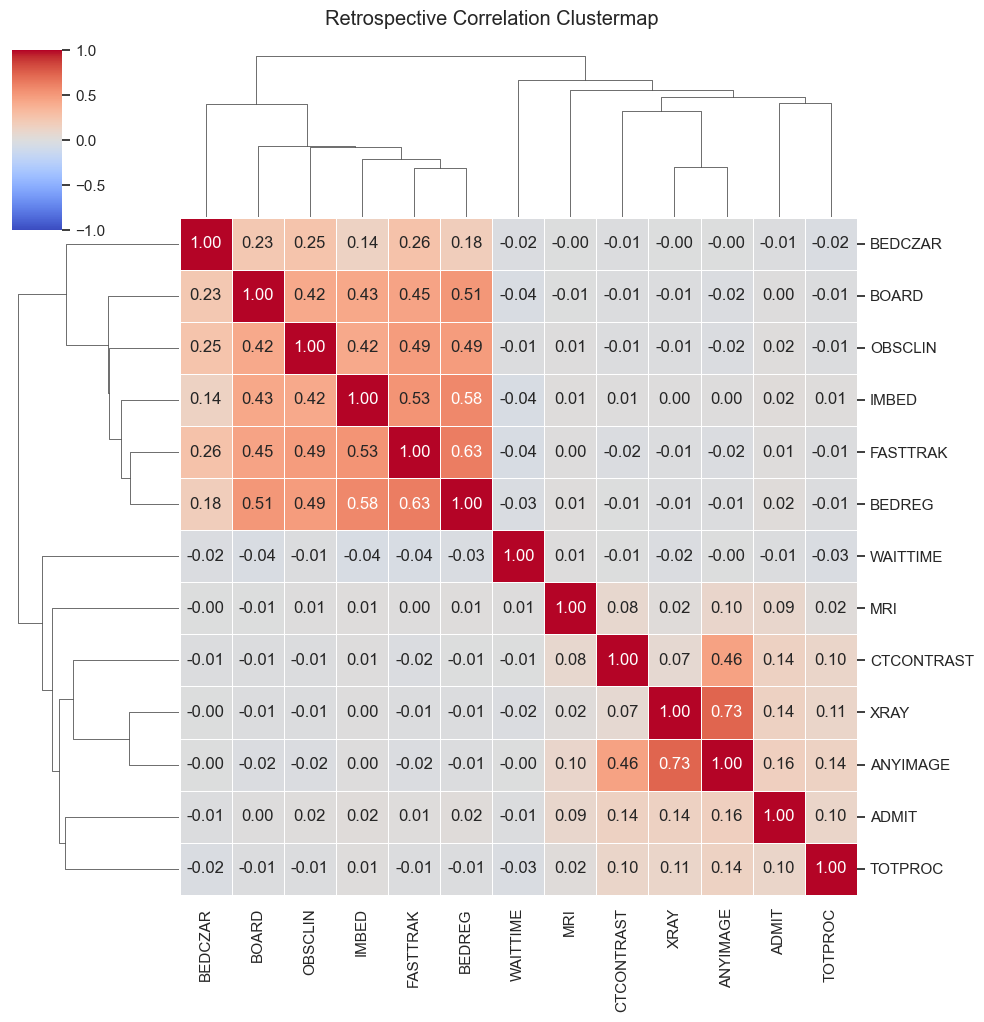

,WAITTIME,FASTTRAK,OBSCLIN,BOARD,ADMIT,MRI,XRAY,CTCONTRAST,ANYIMAGE
WAITTIME,1.000000,-0.044455,-0.011713,-0.036852,-0.012681,0.006488,-0.016282,-0.007124,-0.002532
FASTTRAK,-0.044455,1.000000,0.489352,0.446676,0.010214,0.001826,-0.013954,-0.021166,-0.021674
OBSCLIN,-0.011713,0.489352,1.000000,0.420723,0.015146,0.006662,-0.008043,-0.010418,-0.017617
BOARD,-0.036852,0.446676,0.420723,1.000000,0.001709,-0.006489,-0.014141,-0.014213,-0.023399
ADMIT,-0.012681,0.010214,0.015146,0.001709,1.000000,0.088248,0.143185,0.143756,0.163833
MRI,0.006488,0.001826,0.006662,-0.006489,0.088248,1.000000,0.018005,0.082373,0.101474
XRAY,-0.016282,-0.013954,-0.008043,-0.014141,0.143185,0.018005,1.000000,0.065700,0.727601
CTCONTRAST,-0.007124,-0.021166,-0.010418,-0.014213,0.143756,0.082373,0.065700,1.000000,0.455135
ANYIMAGE,-0.002532,-0.021674,-0.017617,-0.023399,0.163833,0.101474,0.727601,0.455135,1.000000


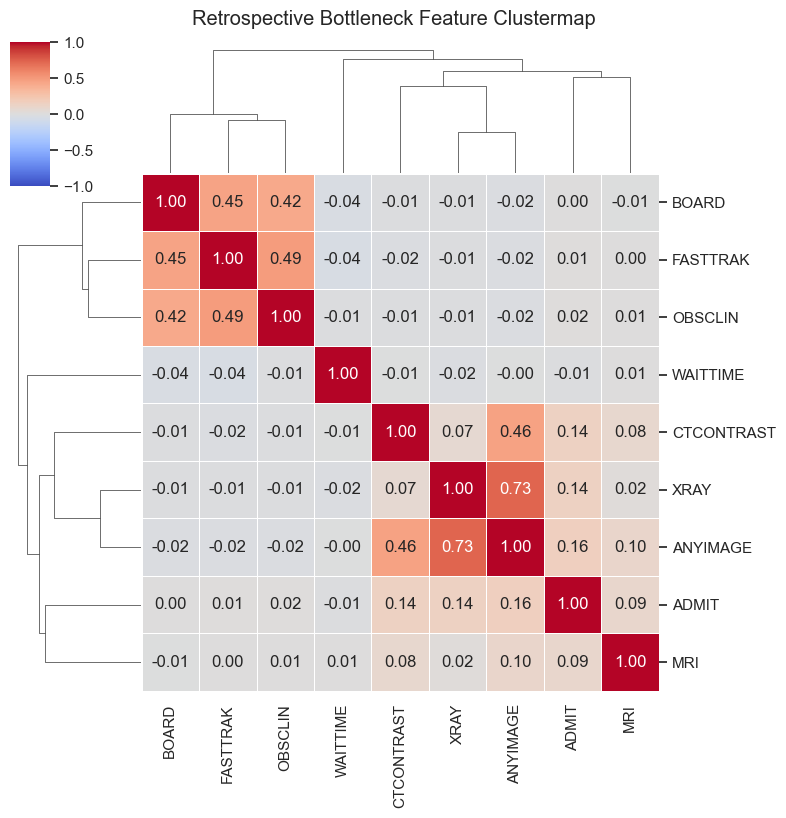

In [14]:
from scipy import stats

retrospective_focus_cols = [
    c for c in [
        'WAITTIME', 'FASTTRAK', 'OBSCLIN', 'BOARD', 'ADMIT',
        'MRI', 'XRAY', 'CT', 'CTCONTRAST', 'ULTRASOUND', 'ANYIMAGE', 'LABTEST', 'TOTPROC',
        'BEDREG', 'IMBED', 'BEDCZAR'
    ]
    if c in analysis_df.columns
]
retrospective_numeric = analysis_df[retrospective_focus_cols].apply(pd.to_numeric, errors='coerce').copy()

binary_flags = [
    flag for flag in ['FASTTRAK', 'OBSCLIN', 'BOARD', 'ADMIT', 'MRI', 'XRAY', 'CT', 'CTCONTRAST', 'ULTRASOUND', 'ANYIMAGE', 'LABTEST']
    if flag in retrospective_numeric.columns
]

def welch_ttest_report(frame, flag_col, positive_value=1):
    subset = frame[[flag_col, 'WAITTIME', 'PATWT']].copy() if 'PATWT' in frame.columns else frame[[flag_col, 'WAITTIME']].copy()
    subset[flag_col] = pd.to_numeric(subset[flag_col], errors='coerce')
    subset['WAITTIME'] = pd.to_numeric(subset['WAITTIME'], errors='coerce')
    subset = subset.dropna(subset=[flag_col, 'WAITTIME'])

    positive = subset.loc[subset[flag_col] == positive_value, 'WAITTIME']
    negative = subset.loc[subset[flag_col] != positive_value, 'WAITTIME']

    if len(positive) < 30 or len(negative) < 30:
        return None

    t_stat, p_value = stats.ttest_ind(positive, negative, equal_var=False, nan_policy='omit')
    pooled_sd = np.sqrt(((positive.var(ddof=1) + negative.var(ddof=1)) / 2))
    cohen_d = (positive.mean() - negative.mean()) / pooled_sd if pooled_sd and pooled_sd > 0 else np.nan

    return {
        'flag': flag_col,
        'positive_value': positive_value,
        'n_positive': int(len(positive)),
        'n_negative': int(len(negative)),
        'mean_positive': positive.mean(),
        'mean_negative': negative.mean(),
        'median_positive': positive.median(),
        'median_negative': negative.median(),
        'weighted_mean_positive': weighted_mean(subset.loc[subset[flag_col] == positive_value, 'WAITTIME'], subset.loc[subset[flag_col] == positive_value, 'PATWT']) if 'PATWT' in subset.columns else np.nan,
        'weighted_mean_negative': weighted_mean(subset.loc[subset[flag_col] != positive_value, 'WAITTIME'], subset.loc[subset[flag_col] != positive_value, 'PATWT']) if 'PATWT' in subset.columns else np.nan,
        'mean_diff': positive.mean() - negative.mean(),
        't_stat': t_stat,
        'p_value': p_value,
        'cohen_d': cohen_d,
    }

if binary_flags:
    ttest_rows = []
    for flag in binary_flags:
        result = welch_ttest_report(analysis_df, flag)
        if result is not None:
            ttest_rows.append(result)

    ttest_df = pd.DataFrame(ttest_rows).sort_values('p_value', ascending=True)
    display(ttest_df)

    plt.figure(figsize=(10, max(3, 0.45 * len(ttest_df))))
    sns.barplot(data=ttest_df, y='flag', x='mean_diff', hue='flag', dodge=False, legend=False, palette='vlag')
    plt.axvline(0, color='black', linewidth=1)
    plt.title('Wait Time Difference for Retrospective Operational Flags')
    plt.xlabel('Mean WAITTIME difference: flag present minus absent')
    plt.ylabel('Retrospective flag')
    plt.tight_layout()
    plt.show()

corr_cols_retrospective = [
    c for c in [
        'WAITTIME', 'FASTTRAK', 'OBSCLIN', 'BOARD', 'ADMIT',
        'MRI', 'XRAY', 'CT', 'CTCONTRAST', 'ULTRASOUND', 'ANYIMAGE', 'LABTEST', 'TOTPROC',
        'BEDREG', 'IMBED', 'BEDCZAR'
    ]
    if c in analysis_df.columns
]
if len(corr_cols_retrospective) >= 2:
    retrospective_corr = analysis_df[corr_cols_retrospective].apply(pd.to_numeric, errors='coerce').corr()
    display(retrospective_corr)

    plt.figure(figsize=(10, 8))
    sns.heatmap(retrospective_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', vmin=-1, vmax=1)
    plt.title('Retrospective Correlation Matrix')
    plt.tight_layout()
    plt.show()

    sns.clustermap(
        retrospective_corr,
        cmap='coolwarm',
        center=0,
        linewidths=0.5,
        figsize=(10, 10),
        annot=True,
        fmt='.2f',
        vmin=-1,
        vmax=1,
    )
    plt.suptitle('Retrospective Correlation Clustermap', y=1.02)
    plt.show()

bottleneck_cols = [c for c in ['WAITTIME', 'FASTTRAK', 'OBSCLIN', 'BOARD', 'ADMIT', 'MRI', 'XRAY', 'CT', 'CTCONTRAST', 'ULTRASOUND', 'ANYIMAGE', 'LABTEST'] if c in analysis_df.columns]
if len(bottleneck_cols) >= 2:
    bottleneck_corr = analysis_df[bottleneck_cols].apply(pd.to_numeric, errors='coerce').corr()
    display(bottleneck_corr)

    sns.clustermap(
        bottleneck_corr,
        cmap='coolwarm',
        center=0,
        linewidths=0.5,
        figsize=(8, 8),
        annot=True,
        fmt='.2f',
        vmin=-1,
        vmax=1,
    )
    plt.suptitle('Retrospective Bottleneck Feature Clustermap', y=1.02)
    plt.show()


,ARRIVAL_HOUR,weighted_n,weighted_wait,weighted_operational_burden,FASTTRAK_rate,OBSCLIN_rate,BOARD_rate,ANYIMAGE_rate,MRI_rate,XRAY_rate,CTCONTRAST_rate,BEDREG_rate,IMBED_rate,BEDCZAR_rate
0,0.0,1.667401e+07,33.274429,5.829772,0.629311,0.424590,0.815070,0.499298,0.011338,0.349458,0.067486,0.886277,0.726066,0.749933
1,1.0,1.482991e+07,34.111782,5.757449,0.601393,0.475166,0.787437,0.459927,0.008107,0.318225,0.060027,0.878803,0.718598,0.774217
2,2.0,1.231603e+07,27.439132,5.715543,0.584489,0.420874,0.810034,0.491368,0.004198,0.335824,0.050267,0.889464,0.706628,0.757748
3,3.0,1.086571e+07,29.004265,5.698857,0.575530,0.460522,0.785346,0.478583,0.007384,0.320025,0.057156,0.866799,0.692315,0.774069
4,4.0,9.741409e+06,27.194982,5.827939,0.657507,0.454528,0.805881,0.488168,0.005224,0.346402,0.075474,0.872989,0.715875,0.747337
5,5.0,1.016076e+07,30.524678,5.787391,0.602814,0.469139,0.790886,0.504761,0.005339,0.324489,0.066847,0.888237,0.695084,0.763648
6,6.0,1.288695e+07,25.113881,5.744221,0.573688,0.465433,0.784490,0.508663,0.013079,0.334913,0.082614,0.862532,0.698062,0.751280
7,7.0,1.950188e+07,23.855879,5.739371,0.609752,0.428018,0.772537,0.536353,0.014986,0.364895,0.079715,0.865200,0.694846,0.721277
8,8.0,2.932538e+07,24.438374,5.650649,0.570362,0.423587,0.761413,0.532390,0.014285,0.368454,0.070109,0.850204,0.682325,0.712999
9,9.0,3.845211e+07,27.314278,5.736449,0.609841,0.427319,0.758230,0.549749,0.015448,0.381223,0.072587,0.853372,0.698704,0.715763


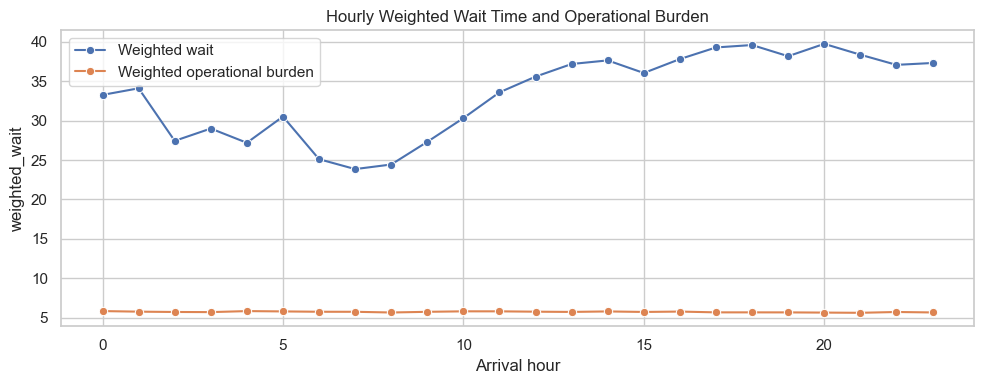

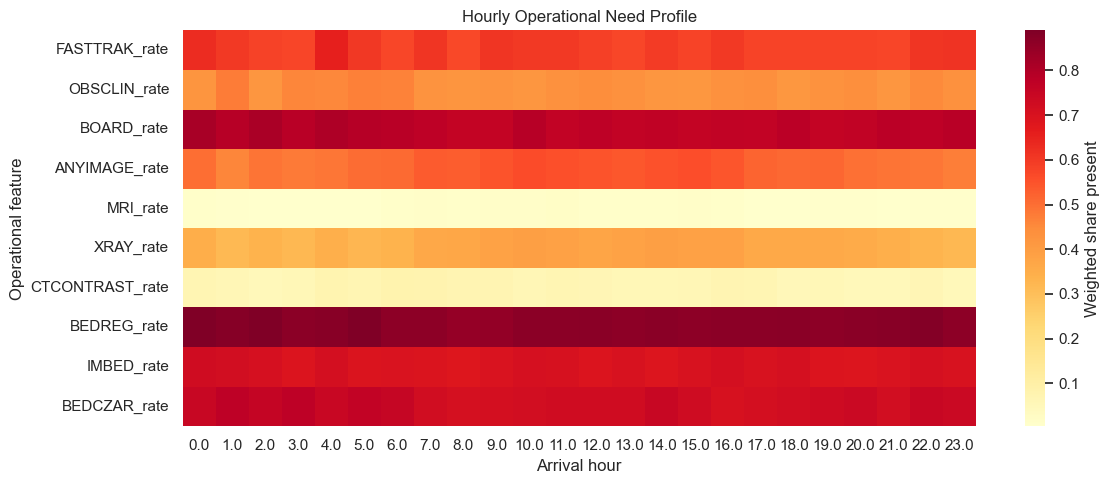

,ARRIVAL_HOUR,weighted_n,weighted_wait,weighted_operational_burden,FASTTRAK_rate,OBSCLIN_rate,BOARD_rate,ANYIMAGE_rate,MRI_rate,XRAY_rate,CTCONTRAST_rate,BEDREG_rate,IMBED_rate,BEDCZAR_rate
0,0.0,1.667401e+07,33.274429,5.829772,0.629311,0.424590,0.815070,0.499298,0.011338,0.349458,0.067486,0.886277,0.726066,0.749933
4,4.0,9.741409e+06,27.194982,5.827939,0.657507,0.454528,0.805881,0.488168,0.005224,0.346402,0.075474,0.872989,0.715875,0.747337
10,10.0,4.457797e+07,30.323148,5.798709,0.601358,0.422495,0.786109,0.561265,0.017220,0.394852,0.062606,0.865485,0.706823,0.718933
11,11.0,4.388518e+07,33.599261,5.797329,0.599132,0.433500,0.764699,0.554749,0.018204,0.387833,0.067082,0.865637,0.703521,0.724301
5,5.0,1.016076e+07,30.524678,5.787391,0.602814,0.469139,0.790886,0.504761,0.005339,0.324489,0.066847,0.888237,0.695084,0.763648
14,14.0,4.161390e+07,37.653333,5.786404,0.598596,0.422618,0.770269,0.553709,0.013032,0.392539,0.057452,0.869958,0.688650,0.748302
16,16.0,4.239635e+07,37.823049,5.767677,0.600700,0.434348,0.768382,0.544803,0.012586,0.387585,0.071679,0.866641,0.713396,0.703870
1,1.0,1.482991e+07,34.111782,5.757449,0.601393,0.475166,0.787437,0.459927,0.008107,0.318225,0.060027,0.878803,0.718598,0.774217


In [17]:
hour_cols = [c for c in ['FASTTRAK', 'OBSCLIN', 'BOARD', 'BOARDED', 'BOARDHOS', 'BEDREG', 'IMBED', 'BEDCZAR', 'MRI', 'XRAY', 'CTCONTRAST', 'ANYIMAGE', 'TOTPROC'] if c in analysis_df.columns]
hour_frame = analysis_df[['ARRIVAL_HOUR', 'WAITTIME', 'PATWT'] + hour_cols].copy() if 'ARRIVAL_HOUR' in analysis_df.columns else pd.DataFrame()

if not hour_frame.empty:
    for col in hour_cols:
        hour_frame[col + '_present'] = pd.to_numeric(hour_frame[col], errors='coerce').eq(1).astype(float)

    burden_cols = [col + '_present' for col in hour_cols if col + '_present' in hour_frame.columns]
    hour_rows = []
    for hour, group in hour_frame.dropna(subset=['ARRIVAL_HOUR', 'WAITTIME', 'PATWT']).groupby('ARRIVAL_HOUR'):
        weights = pd.to_numeric(group['PATWT'], errors='coerce')
        valid = weights.notna() & (weights > 0)
        group = group.loc[valid].copy()
        weights = weights.loc[valid]
        if group.empty:
            continue

        burden_score = group[burden_cols].fillna(0).sum(axis=1)
        row = {
            'ARRIVAL_HOUR': hour,
            'weighted_n': weights.sum(),
            'weighted_wait': weighted_mean(group['WAITTIME'], weights),
            'weighted_operational_burden': weighted_mean(burden_score, weights),
        }
        for col in ['FASTTRAK', 'OBSCLIN', 'BOARD', 'ANYIMAGE', 'MRI', 'XRAY', 'CTCONTRAST', 'BEDREG', 'IMBED', 'BEDCZAR']:
            present_col = col + '_present'
            if present_col in group.columns:
                row[col + '_rate'] = weighted_mean(group[present_col], weights)
        hour_rows.append(row)

    hour_summary = pd.DataFrame(hour_rows).sort_values('ARRIVAL_HOUR')
    display(hour_summary)

    plt.figure(figsize=(10, 4))
    sns.lineplot(data=hour_summary, x='ARRIVAL_HOUR', y='weighted_wait', marker='o', label='Weighted wait')
    sns.lineplot(data=hour_summary, x='ARRIVAL_HOUR', y='weighted_operational_burden', marker='o', label='Weighted operational burden')
    plt.title('Hourly Weighted Wait Time and Operational Burden')
    plt.xlabel('Arrival hour')
    plt.tight_layout()
    plt.show()

    heatmap_cols = [col + '_rate' for col in ['FASTTRAK', 'OBSCLIN', 'BOARD', 'ANYIMAGE', 'MRI', 'XRAY', 'CTCONTRAST', 'BEDREG', 'IMBED', 'BEDCZAR'] if col + '_rate' in hour_summary.columns]
    if heatmap_cols:
        heatmap_df = hour_summary[['ARRIVAL_HOUR'] + heatmap_cols].set_index('ARRIVAL_HOUR')
        plt.figure(figsize=(12, 5))
        sns.heatmap(heatmap_df.T, cmap='YlOrRd', cbar_kws={'label': 'Weighted share present'})
        plt.title('Hourly Operational Need Profile')
        plt.xlabel('Arrival hour')
        plt.ylabel('Operational feature')
        plt.tight_layout()
        plt.show()

    display(hour_summary.sort_values('weighted_operational_burden', ascending=False).head(8))